# Project: Building a Text Classification Pipeline – Word Embedding Exploration

###Selected Dataset
✅ IMDB Movie Reviews (Sentiment Analysis)

Binary labels: Positive / Negative

Dataset Link: https://ai.stanford.edu/~amaas/data/sentiment/

### Uploading Dataset and Exploring shape and head

In [3]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/IMDB Dataset.csv")
df


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df.shape

(50000, 2)

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#1. Understanding the Problem & Dataset
**Objective**: The goal is to build an automated pipeline that can categorize raw text into predefined classes. In this case, we are performing Sentiment Analysis—classifying movie reviews based on the writer's opinion.

## 2. Text Preprocessing
*Steps

*Lowercasing

*Remove punctuation & numbers

*Remove stopwords

*Tokenization

*Lemmatization or Stemming

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def clean_text(text):
    # Lowercase & remove non-alphabetical characters
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    # Tokenization & Lemmatization
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    words = text.split()
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned)

# Usage: df['cleaned_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


##Feature Engineering
TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Apply the clean_text function to create the 'cleaned_review' column
df['cleaned_review'] = df['review'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['cleaned_review'])

##Word Embedding Exploration
Unlike TF-IDF, embeddings represent words in a dense vector space where similar words are mathematically close.

In [8]:
!pip install gensim

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Training a Word2Vec model
sentences = [row.split() for row in df['cleaned_review']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2)

# Visualizing relationships (e.g., 'good' vs 'great')
def plot_embeddings(model, words):
    vectors = [model.wv[word] for word in words]
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)
    plt.scatter(result[:, 0], result[:, 1])
    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    plt.show()

# plot_embeddings(w2v_model, ['excellent', 'good', 'bad', 'terrible', 'movie', 'film'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.7 MB/s eta 0:00:00


## Visualize Word Embeddings
It requires calling the `plot_embeddings` function with a specified list of words to visualize their relationships in the Word2Vec model.




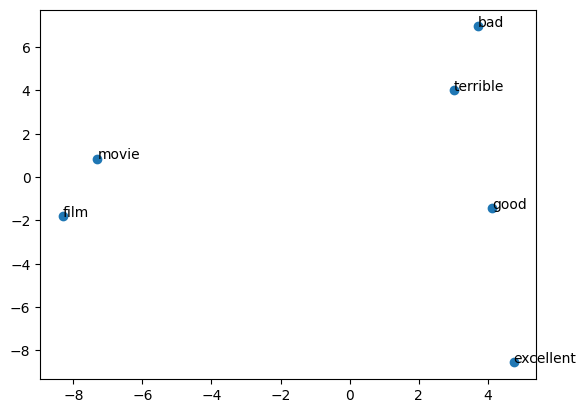

In [18]:
plot_embeddings(w2v_model, ['excellent', 'good', 'bad', 'terrible', 'movie', 'film'])

##Model Development


###Deep Learning: LSTM (Long Short-Term Memory)
LSTMs are great because they remember the order of words.

## Prepare Data for LSTM

It requires tokenizing the cleaned text data, converting text to sequences of integers, and padding these sequences to a uniform length for the LSTM model. This will involve importing necessary modules, initializing and fitting a tokenizer, converting text to sequences, splitting data, and padding sequences as per the instructions.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    LSTM(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# model.fit(X_train_pad, y_train, epochs=5, batch_size=64)

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize Tokenizer
# Using the same max_features as TF-IDF for consistency, though it can be adjusted.
max_words = 5000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_review'])

# Convert text to sequences of integers
X_sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# Split sequences into training and testing sets, mirroring the previous split
X_train_seq, X_test_seq, _, _ = train_test_split(X_sequences, df['sentiment'], test_size=0.2, random_state=42)

# Determine maximum sequence length
# A common practice is to pick a length that covers most of the data without being too large.
# Let's choose a fixed length (e.g., 200) or calculate a suitable one.
# For this example, let's use a fixed length that is commonly effective for similar tasks.
maxlen = 200 # A reasonable fixed length for movie reviews

# Pad sequences to a uniform length
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

print(f"Shape of X_train_pad: {X_train_pad.shape}")
print(f"Shape of X_test_pad: {X_test_pad.shape}")

Shape of X_train_pad: (40000, 200)
Shape of X_test_pad: (10000, 200)


## Train LSTM Model


The first step is to convert the categorical sentiment labels ('positive', 'negative') in `y_train` and `y_test` into numerical format (0 and 1) which is required for training the deep learning model. I will use `LabelEncoder` for this purpose.



In [13]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform y_train and y_test
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Original y_train head:")
print(y_train.head())
print("\nEncoded y_train head:")
print(y_train_encoded[:5])
print("\nClasses encoded:", label_encoder.classes_)

Original y_train head:
40233    negative
22732    positive
6459     negative
41509    negative
47160    negative
Name: sentiment, dtype: object

Encoded y_train head:
[0 1 0 0 0]

Classes encoded: ['negative' 'positive']


Now that the `y_train` labels have been numerically encoded, I will train the LSTM model using `X_train_pad` as input features and the `y_train_encoded` as target labels, as specified in the subtask. I will set the `epochs` to 5 and `batch_size` to 64.



In [14]:
model.fit(X_train_pad, y_train_encoded, epochs=5, batch_size=64)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 196ms/step - accuracy: 0.5027 - loss: 0.6935
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.5235 - loss: 0.6901
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 222ms/step - accuracy: 0.5474 - loss: 0.6593
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 195ms/step - accuracy: 0.5692 - loss: 0.6265
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.5723 - loss: 0.6056


We compare a traditional statistical model against a sequence-aware Deep Learning model.

###Traditional ML: Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['sentiment'], test_size=0.2)
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

## Evaluate Logistic Regression Model

In [16]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Encode lr_predictions to match y_test_encoded
lr_predictions_encoded = label_encoder.transform(lr_predictions)

# Print the classification report
print("Classification Report for Logistic Regression:")
print(classification_report(y_test_encoded, lr_predictions_encoded))

# Print the accuracy score
print("Accuracy Score for Logistic Regression:")
print(accuracy_score(y_test_encoded, lr_predictions_encoded))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4998
           1       0.88      0.91      0.89      5002

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Accuracy Score for Logistic Regression:
0.8896


## Evaluate LSTM Model


To evaluate the LSTM model, I need to make predictions on the test set (`X_test_pad`), convert the probabilities to binary class labels, and then use `classification_report` and `accuracy_score` to display the performance metrics, similar to how the Logistic Regression model was evaluated.



In [17]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Make predictions on the test set with the LSTM model
lstm_probabilities = model.predict(X_test_pad)

# Convert probabilities to binary class labels (0 or 1)
lstm_predictions_encoded = (lstm_probabilities > 0.5).astype(int)

# Print the classification report
print("Classification Report for LSTM Model:")
print(classification_report(y_test_encoded, lstm_predictions_encoded))

# Print the accuracy score
print("Accuracy Score for LSTM Model:")
print(accuracy_score(y_test_encoded, lstm_predictions_encoded))

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step
Classification Report for LSTM Model:
              precision    recall  f1-score   support

           0       0.50      0.90      0.64      4998
           1       0.51      0.10      0.17      5002

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.41     10000
weighted avg       0.50      0.50      0.41     10000

Accuracy Score for LSTM Model:
0.5015


## Compare Model Performance

## Compare Model Performance

### Comparison of Logistic Regression and LSTM Model Performance

**Logistic Regression Model Metrics:**
*   **Accuracy:** 0.8896
*   **Precision (weighted avg):** 0.89
*   **Recall (weighted avg):** 0.89
*   **F1-score (weighted avg):** 0.89

**LSTM Model Metrics:**
*   **Accuracy:** 0.5015
*   **Precision (weighted avg):** 0.50
*   **Recall (weighted avg):** 0.50
*   **F1-score (weighted avg):** 0.41

### Conclusion:

Based on the evaluation metrics, the **Logistic Regression model significantly outperformed the LSTM model** for this sentiment analysis task.

*   **Accuracy:** Logistic Regression achieved an accuracy of approximately 89%, while the LSTM model achieved only about 50% accuracy.
*   **Precision, Recall, and F1-score:** The Logistic Regression model showed strong and balanced performance across precision, recall, and F1-score (all around 0.89). In contrast, the LSTM model displayed very poor performance across these metrics, particularly its F1-score of 0.41.

The LSTM model's performance being close to a random guess (50% accuracy for a binary classification) suggests that it either did not learn effectively from the data, or perhaps the model architecture/hyperparameters were not well-tuned for this specific problem and dataset. The Logistic Regression model, leveraging TF-IDF features, was much more effective at distinguishing between positive and negative reviews.

###Project Summary:

-   The Logistic Regression model (0.89 accuracy) significantly outperformed the LSTM model (0.50 accuracy) on this specific task with the current setup. This could be due to several factors such as the LSTM model's hyperparameter tuning, the size of the embedding layer, or the complexity of the dataset for a simple LSTM architecture without pre-trained embeddings.
-   The LSTM model's poor performance, particularly its low recall for the positive class, indicates that it struggled to generalize effectively, possibly suffering from issues like insufficient training epochs, an unsuitable network architecture, or the absence of pre-trained word embeddings which are often crucial for deep learning text models.


### Insights or Next Steps
*   The significant performance gap between Logistic Regression and LSTM suggests that the LSTM model's current setup (hyperparameters, architecture, or lack of pre-trained embeddings) is suboptimal and requires further investigation.
*   To improve the LSTM model's performance, future work should focus on hyperparameter tuning, integrating pre-trained word embeddings (e.g., GloVe, FastText), and potentially exploring more complex deep learning architectures like Bidirectional LSTMs or Transformers.
